# Definitions

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
os.environ['OMP_NUM_THREADS'] = '10'
import matplotlib
import math
import warnings
from matplotlib import pyplot as plt
import numpy as np
import euclidemu2
import scipy
import cosmolike_desy1xplanck_interface as ci
from getdist import IniFile
import itertools
import iminuit
import functools
from scipy.interpolate import interp1d
print(sys.version)
print(os.getcwd())

# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'

# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# BE CAREFUL: you need texlive-latex-base texlive-latex-extra texlive-fonts-recommended dvipng ghostscript cm-super
matplotlib.rcParams['text.usetex'] = True
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))


Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.


3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/desy1xplanck


In [2]:
# IMPORT CAMB
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

# IMPORT SHARED NOTEBOOK UTILITIES (cosmolike_core)
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/cosmolike_core')
import cosmolike_notebook_utils as cnu
print('Using cosmolike_notebook_utils installed at %s'%(os.path.dirname(cnu.__file__)))


# IMPORT THE PROJECT'S NOTEBOOK WRAPPERS (projects/desy1xplanck/interface):
# the probe, chi2, and response wrappers every notebook
# of this project shares
import cosmolike_desy1xplanck_notebook_wrappers as nw
print('Using notebook wrappers installed at %s'%(nw.__file__))

Using CAMB 1.6.7 installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/camb
Using cosmolike_notebook_utils installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/cosmolike_core/cosmolike_notebook_utils
Using notebook wrappers installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/desy1xplanck/interface/cosmolike_desy1xplanck_notebook_wrappers.py


In [3]:
CAMBAccuracyBoost = 1.0
non_linear_emul = 2
CLprobe="xi"

path= "../../external_modules/data/desy1xplanck"
data_file="Y3xPlanckPR4.dataset"

IA_model = 0
IA_redshift_evolution = 3
IA_code = 0  # 0 = C FASTPT, 1 = Python FAST-PT (NLA always uses 0)

ntheta = 30
theta_min_arcmin = 0.25
theta_max_arcmin = 250
lmax = 75000

# hand this notebook's yaml-mirroring values to the shared wrappers
nw.configure(lmax=lmax,
             ntheta=ntheta,
             theta_min_arcmin=theta_min_arcmin,
             theta_max_arcmin=theta_max_arcmin,
             non_linear_emul=non_linear_emul)

In [4]:
# The project fiducial point lives in the wrappers module
# (interface/cosmolike_desy1xplanck_notebook_wrappers.py), shared by
# every notebook. The names are imported so the sweep cells below can
# build shifted vectors from them; override any value per call
# instead, e.g. nw.get_chi2(omegam=0.31).
from cosmolike_desy1xplanck_notebook_wrappers import (
    As_1e9, ns, H0, omegab, omegam, mnu, w, w0pwa,
    DES_A1_1, DES_A1_2,
    DES_DZ_S1, DES_DZ_S2, DES_DZ_S3, DES_DZ_S4,
    DES_M1, DES_M2, DES_M3, DES_M4,
    DES_DZ_L1, DES_DZ_L2, DES_DZ_L3, DES_DZ_L4, DES_DZ_L5, DES_DZ_L6,
    DES_DZ2_L1, DES_DZ2_L2, DES_DZ2_L3, DES_DZ2_L4, DES_DZ2_L5, DES_DZ2_L6,
    DES_B1_1, DES_B1_2, DES_B1_3, DES_B1_4, DES_B1_5, DES_B1_6,
    DES_BMAG_1, DES_BMAG_2, DES_BMAG_3, DES_BMAG_4, DES_BMAG_5, DES_BMAG_6,
    DES_PM1, DES_PM2, DES_PM3, DES_PM4, DES_PM5, DES_PM6)

In [5]:
# get_camb_cosmology lives in cosmolike_core, shared by every project's
# notebooks; call it as cnu.get_camb_cosmology (imported above):
# external_modules/code/cosmolike_core/cosmolike_notebook_utils


In [6]:
# C_ss_tomo_limber lives in this project's interface/
# (cosmolike_desy1xplanck_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.C_ss_tomo_limber.

In [7]:
# xi lives in this project's interface/
# (cosmolike_desy1xplanck_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.xi.

In [8]:
# Init Cosmolike (the full sequence lives in nw.init_cosmolike)
ini = nw.init_cosmolike()
allsims = nw.allsims

# Basic Plot routines

In [9]:
# plot_C_ss_tomo_limber lives in cosmolike_core (shared); call it as
# cnu.plot_C_ss_tomo_limber (imported above)


In [10]:
# plot_xi lives in cosmolike_core (shared); call it as cnu.plot_xi
# (imported above)

# Let's plot how cosmological and nuisance parameters affect $C_{\ell}^{EE}$

In [11]:
lmin = 100.
lmax = 4500.
ell = np.arange(lmin, lmax, 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.2, 0.4, 0.02)     
C_ss = []
for x in param:
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, omegam=x)
    C_ss.append(Cl)

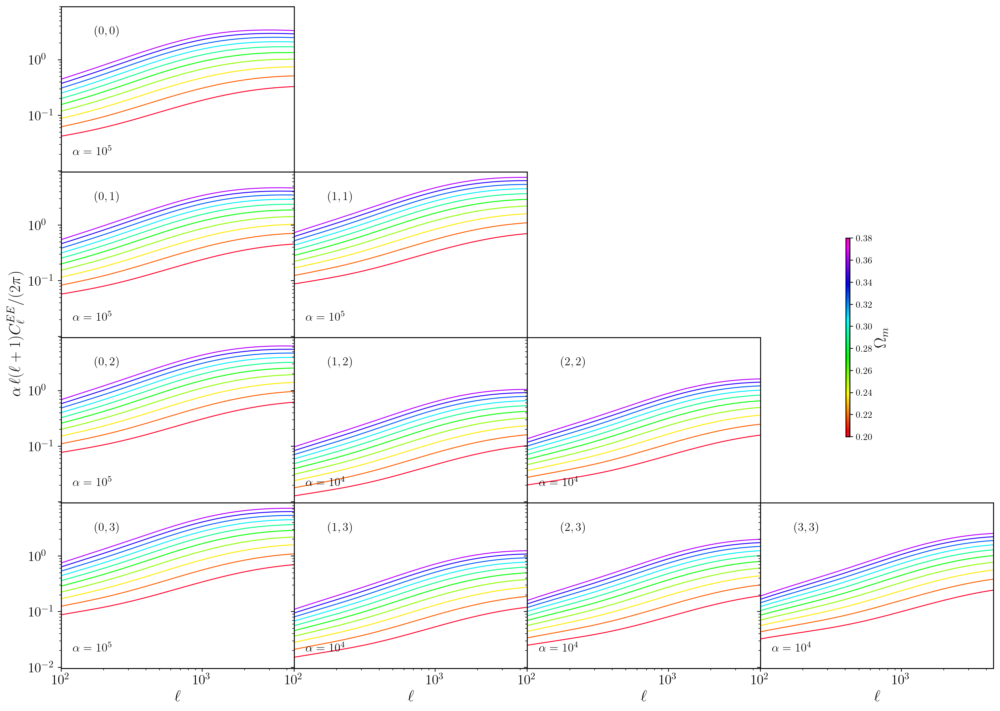

In [12]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          param=param,
                          colorbarlabel="$\Omega_m$",
                          yaxislabelsize = 17,
                          xaxislabelsize = 17,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          figsize = (18, 13),
                          lmin = lmin,
                          lmax = lmax,
                          wspace=0.4,
                          rescale=1,
                          ydecades=4)

In [13]:
lmin = 100.
lmax = 4500.
ell = np.arange(lmin,lmax, 20.) # Make sure arange are with float numbers (otherwise there are aliasing problems)
param = np.arange(0.85, 1.1, 0.02)
C_ss = []
for x in param:
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, ns=x)
    C_ss.append(Cl)
# Plot the Ratio over ref cosmology
(ref, tmp) = nw.C_ss_tomo_limber(ell=ell)

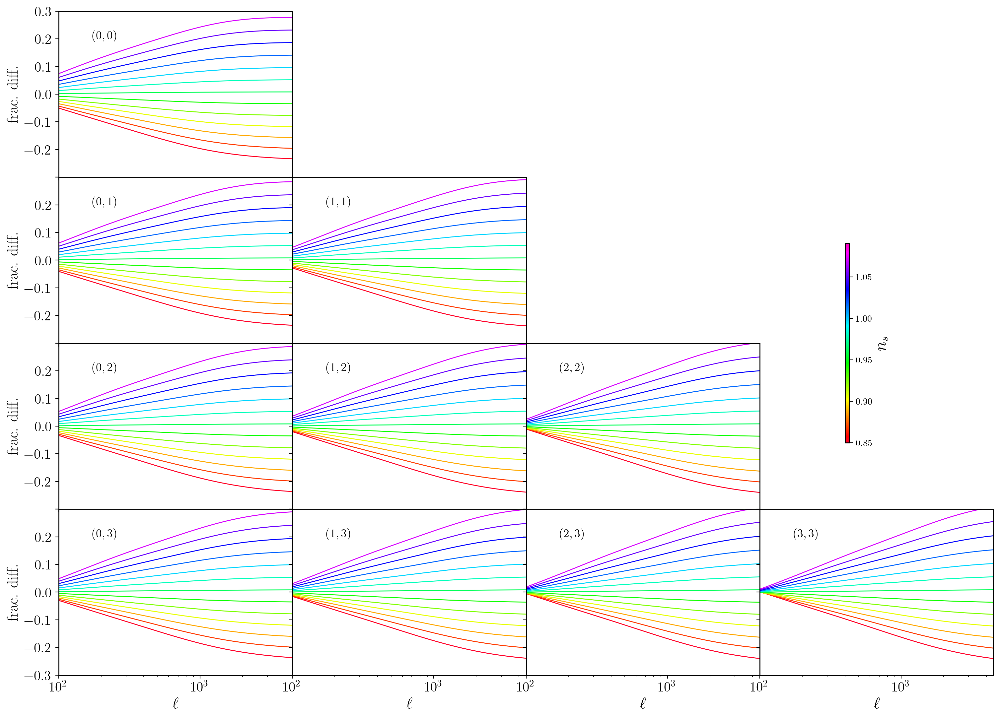

In [14]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=ref,
                          param=param,
                          colorbarlabel="$n_s$",
                          figsize = (18, 13),
                          yaxislabelsize = 17,
                          xaxislabelsize = 17,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          lmin = lmin,
                          lmax = lmax,
                          ylim = [0.7,1.3],
                          wspace=0.4)

In [15]:
lmin = 100.
lmax = 4500.
ell = np.arange(lmin, lmax, 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.0, 3, 0.1)     
C_ss = []
for x in param:
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, A1 = [x, DES_A1_2, 0, 0])
    C_ss.append(Cl)

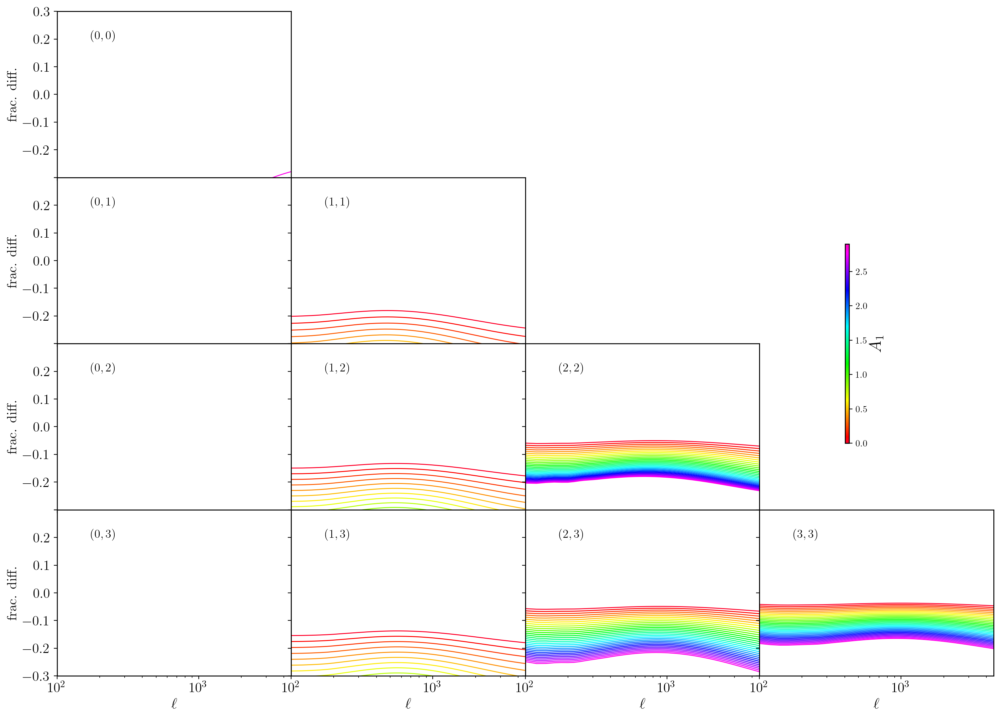

In [16]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=ref,
                          param=param,
                          colorbarlabel="$A_1$",
                          figsize = (18, 13),
                          yaxislabelsize = 15,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          lmin = lmin,
                          lmax = lmax,
                          ylim = [0.7,1.3],
                          wspace=0.4)

In [17]:
lmin = 100.
lmax = 4500.
ell = np.arange(lmin, lmax, 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(-2, 2, 0.1)     
C_ss = []
for x in param:
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, A1 = [DES_A1_1, x, 0, 0])
    C_ss.append(Cl)

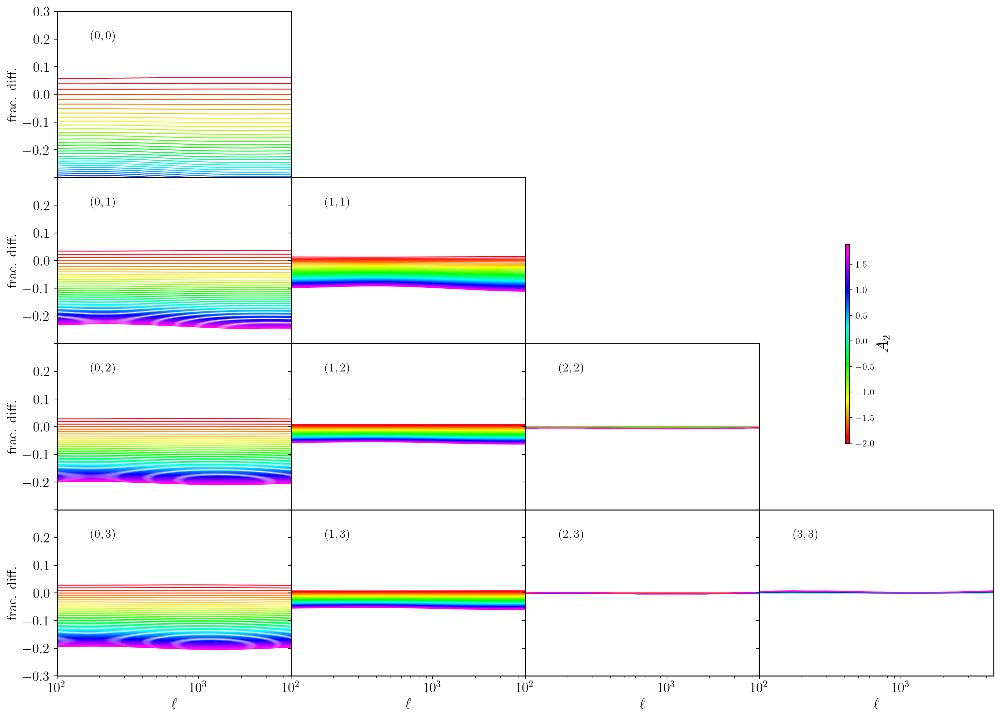

In [18]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=ref,
                          param=param,
                          colorbarlabel="$A_2$",
                          figsize = (18, 13),
                          yaxislabelsize = 15,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          lmin = lmin,
                          lmax = lmax,
                          ylim = [0.7,1.3],
                          wspace=0.4)

# Let's plot how cosmological and nuisance parameters affect $\xi(\theta)$

In [19]:
param = np.arange(0.2, 0.4, 0.02)
xi_theta = []
for x in param:
    xi_theta.append(nw.xi(omegam = x))

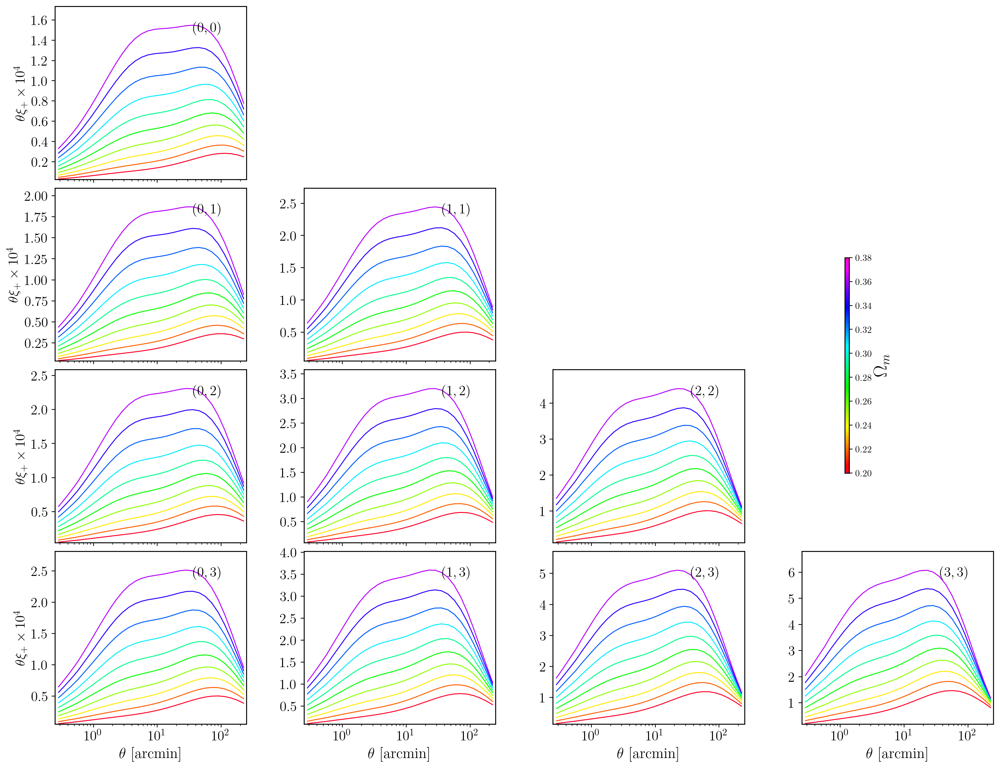

In [20]:
cnu.plot_xi(pm = 1,
            xi = xi_theta,
            param = param,
            colorbarlabel = "$\Omega_m$",
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (18, 14),
            thetashow=[0.25,250],
            wspace=0.3,
            rescale=None)

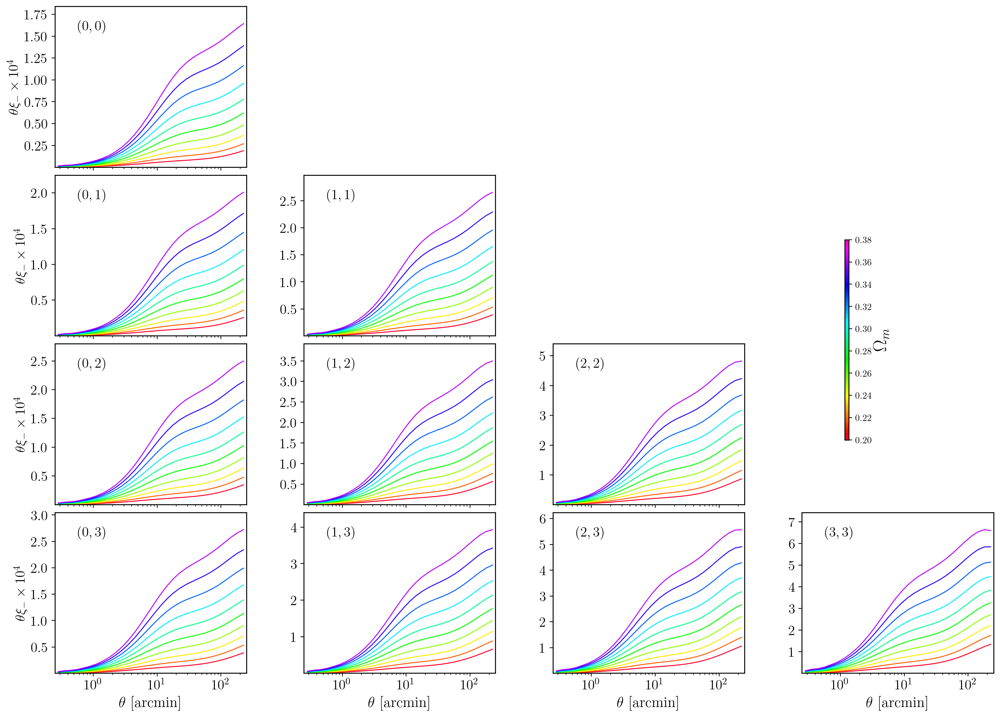

In [21]:
cnu.plot_xi(pm = -1,
            xi = xi_theta,
            param = param,
            colorbarlabel = "$\Omega_m$",
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (18, 13),
            thetashow=[0.25,250],
            wspace=0.3,
            rescale=None)

# Can we change the binning on $\xi(\theta)$ w/o restarting the kernel? Yes!
Why this is a nontrivial question? Because Cosmolike uses static variables to cache Glplus and Glminus

In [22]:
nthetas=[9, 12, 17, 44]
result = []
for x in nthetas:
    result.append(nw.xi(ntheta=x))

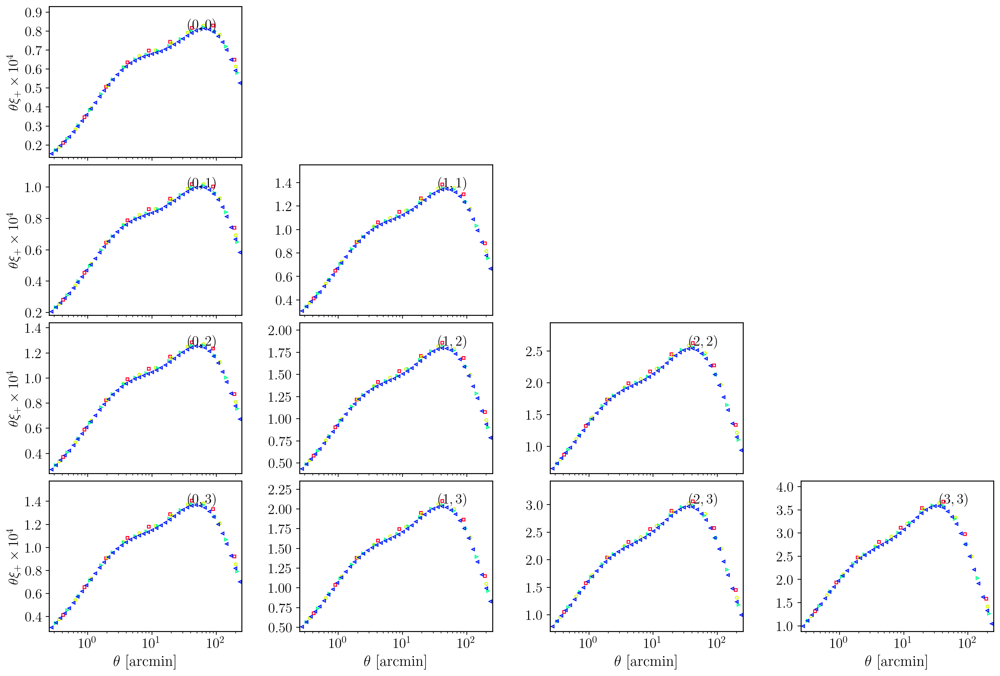

In [23]:
cnu.plot_xi(pm = 1,
            xi = result,
            marker=['s', 'o', ">", "<"],
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (18, 12),
            thetashow=[0.25,250],
            wspace=0.3,
            rescale=None)

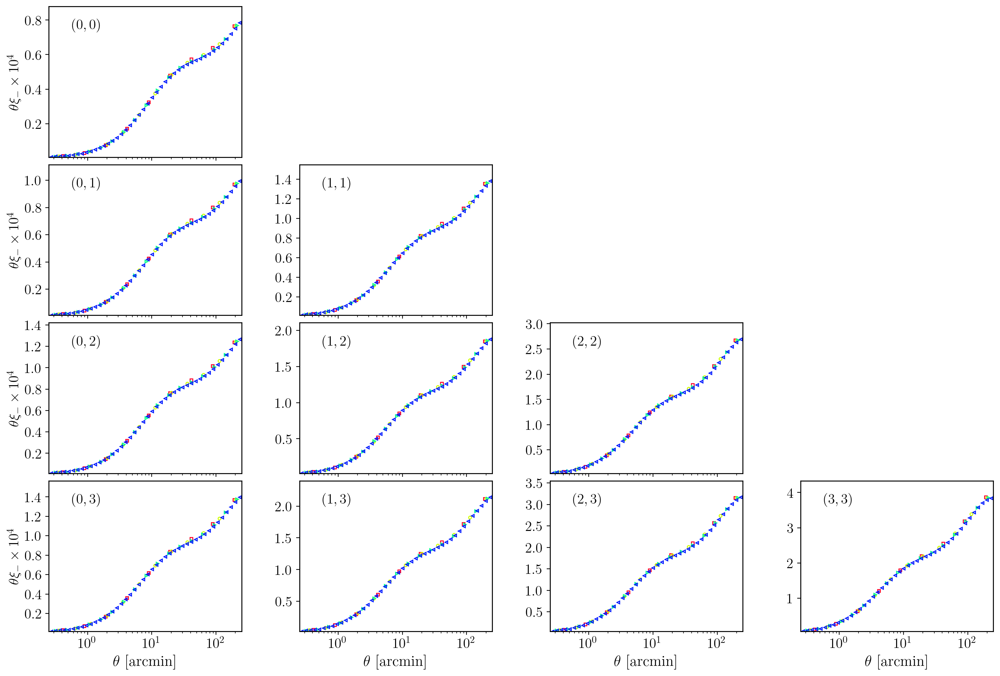

In [24]:
cnu.plot_xi(pm = -1,
            xi = result,
            marker=['s', 'o', ">", "<"],
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (18, 12),
            thetashow=[0.25,250],
            wspace=0.3,
            rescale=None)

# Add Baryon Contamination to $C_\ell^{\rm EE}$ and $\xi(\theta)$ data vectors

In [25]:
lmin = 100.
lmax = 4500.
ell = np.arange(lmin, lmax, 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = ("TNG100-1", "HzAGN-1", "mb2-1", "illustris-1", "eagle-1", "owls_AGN-1", "owls_AGN-2", "owls_AGN-3", "BAHAMAS-2")
C_ss = []
for x in param:
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, baryon_sims=x,allsims=allsims)
    C_ss.append(Cl)
    
# Plot the Ratio over ref cosmology
(C_ss_ref, tmp) = nw.C_ss_tomo_limber(ell=ell)

xi_theta = []
for x in param:
    xi_theta.append(nw.xi(baryon_sims=x,allsims=allsims, ntheta=40, AccuracyBoost=1.0))

xi_theta_ref = nw.xi(ntheta=40, AccuracyBoost=1.0)

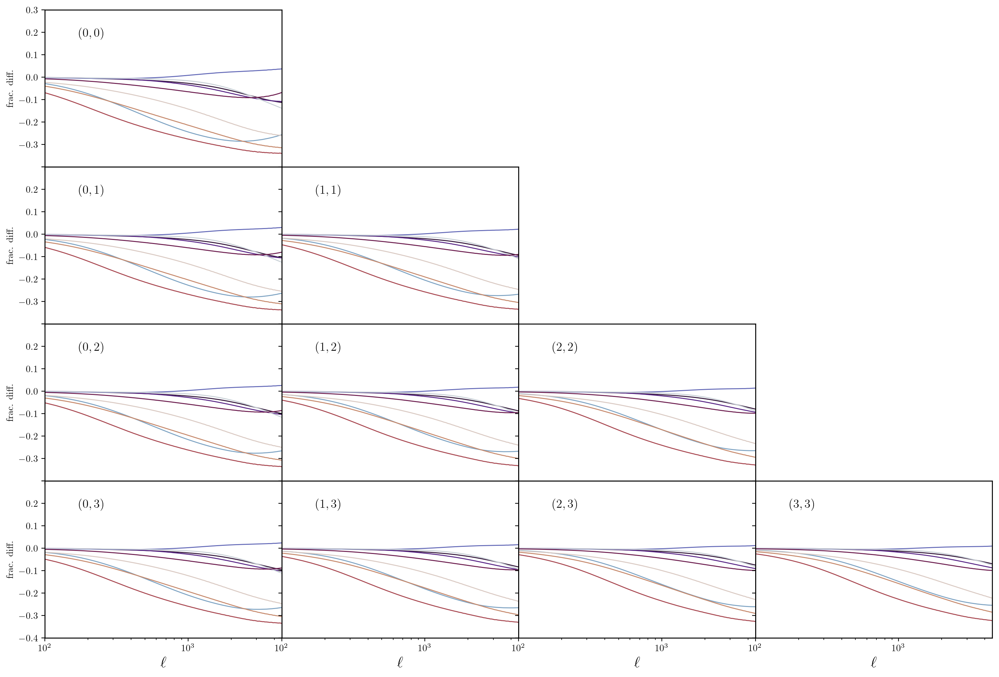

In [26]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          lmin=lmin,
                          lmax=lmax,
                          cmap="twilight_shifted",
                          yaxislabelsize = 10,
                          xaxisticklabelsize=10,
                          yaxisticklabelsize=10,
                          ylim=(0.6,1.3),
                          figsize = (18, 12),
                          wspace=0.4)

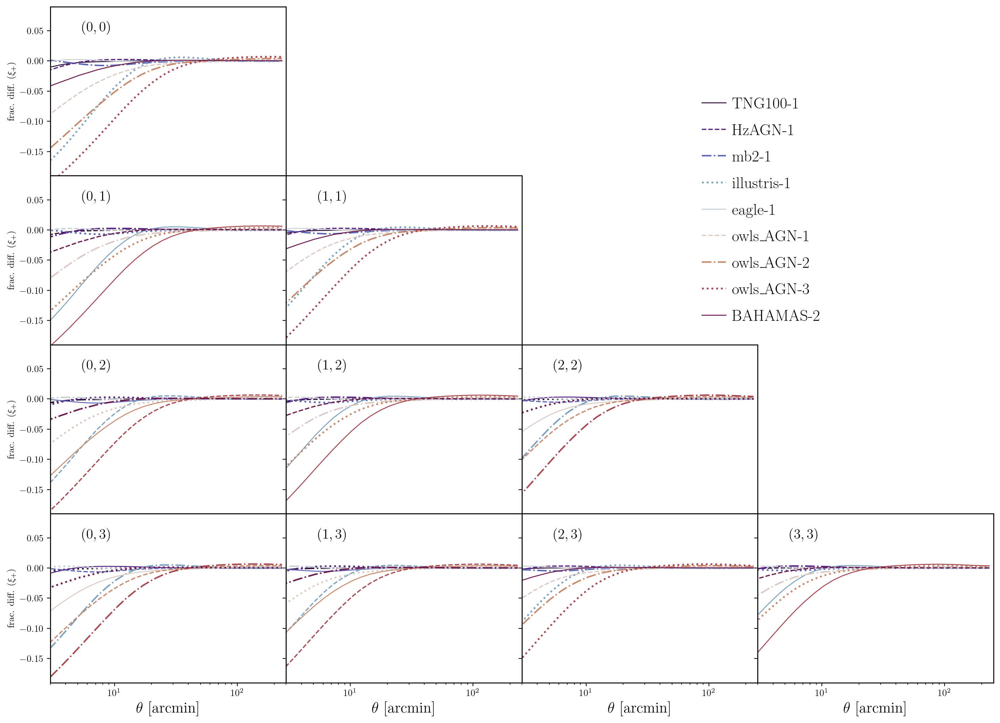

In [27]:
matplotlib.rcParams['legend.fontsize'] = 17
cnu.plot_xi(pm = 1,
            param=None,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            cmap="twilight_shifted",
            ylim=(0.81,1.09),
            linewidth=[1.0, 1.3, 1.6, 1.9],
            linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
            legend = param,
            legendloc=(0.7,0.55),
            bintextpos = [[0.2, 0.875],[0.2,0.875]],
            yaxislabelsize = 10,
            xaxisticklabelsize=10,
            yaxisticklabelsize=10,
            figsize = (18, 13),
            wspace=0.4)

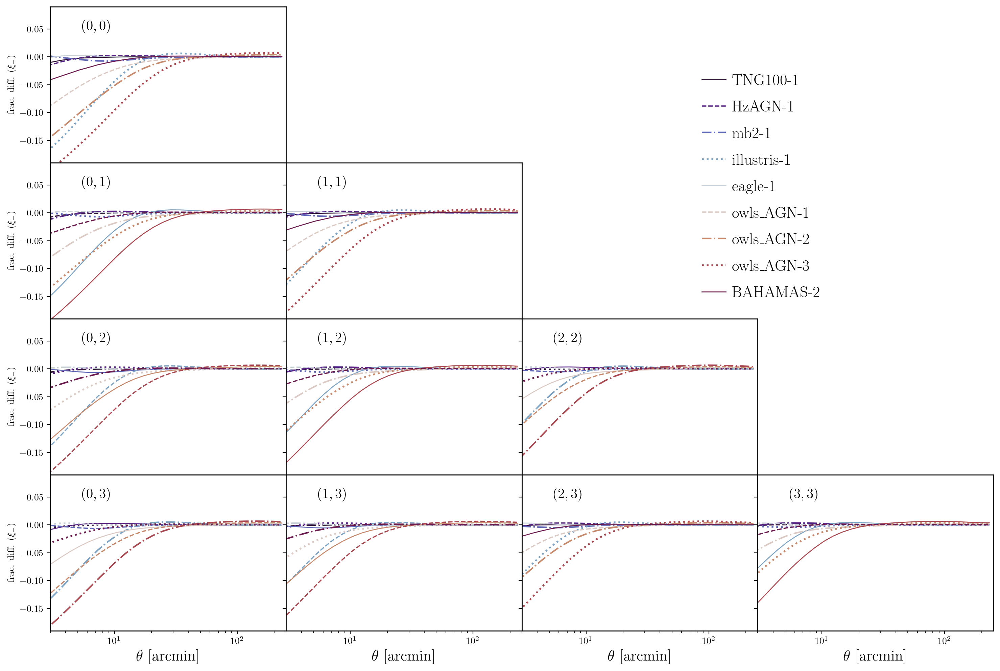

In [28]:
cnu.plot_xi(pm = -1,
            param=None,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            cmap="twilight_shifted",
            ylim=(0.81,1.09),
            linewidth=[1.0, 1.3, 1.6, 1.9],
            linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
            legend = param,
            legendloc=(0.7,0.55),
            bintextpos = [[0.2, 0.875],[0.2,0.875]],
            yaxislabelsize = 10,
            xaxisticklabelsize=10,
            yaxisticklabelsize=10,
            figsize = (18, 12),
            wspace=0.4)

# Check how CAMB and Cosmolike Accuracy Boost affect $C_\ell^{\rm EE}$ and $\xi(\theta)$ data vectors (and $\chi^2)$

In [29]:
lmin = 100.
lmax = 6500.
ell = np.arange(lmin, lmax, 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(1.0, 10.0, 0.5)
C_ss = []
for x in param:
    # Change only Cosmolike Settings
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x))
    C_ss.append(Cl)
# Plot the Ratio over ref cosmology
(C_ss_ref, tmp) = nw.C_ss_tomo_limber(ell=ell,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)

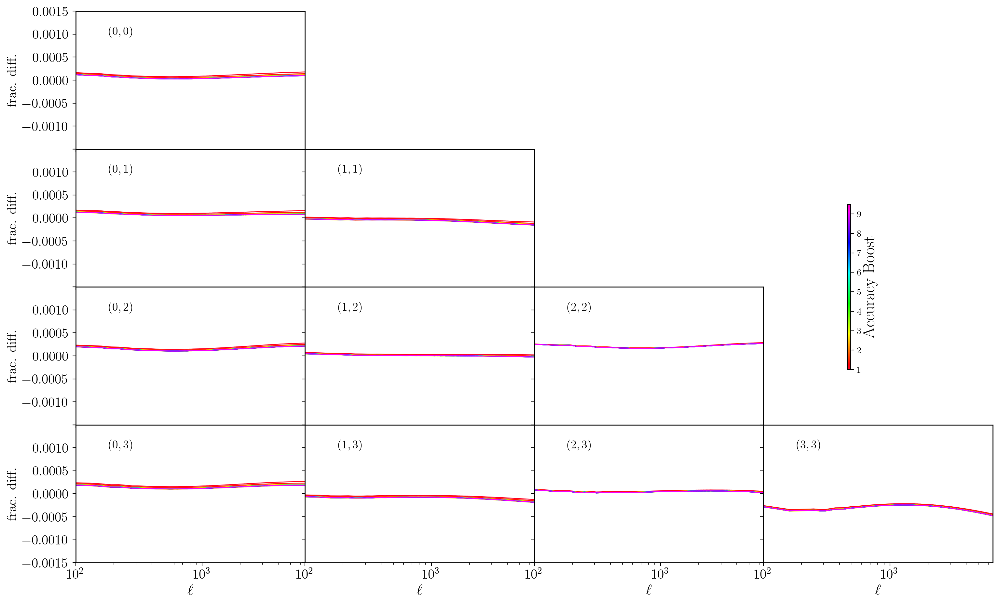

In [30]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          param=param,
                          lmin=lmin,
                          lmax=lmax,
                          ylim=(0.9985,1.0015),
                          colorbarlabel="Accuracy Boost",
                          yaxislabelsize = 15,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          figsize = (18, 11),
                          wspace=0.4)

In [31]:
param = np.arange(0,10.0,1.0)
xi_theta_ref = nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)
xi_theta = []
for x in param:
    xi_theta.append(nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x)))

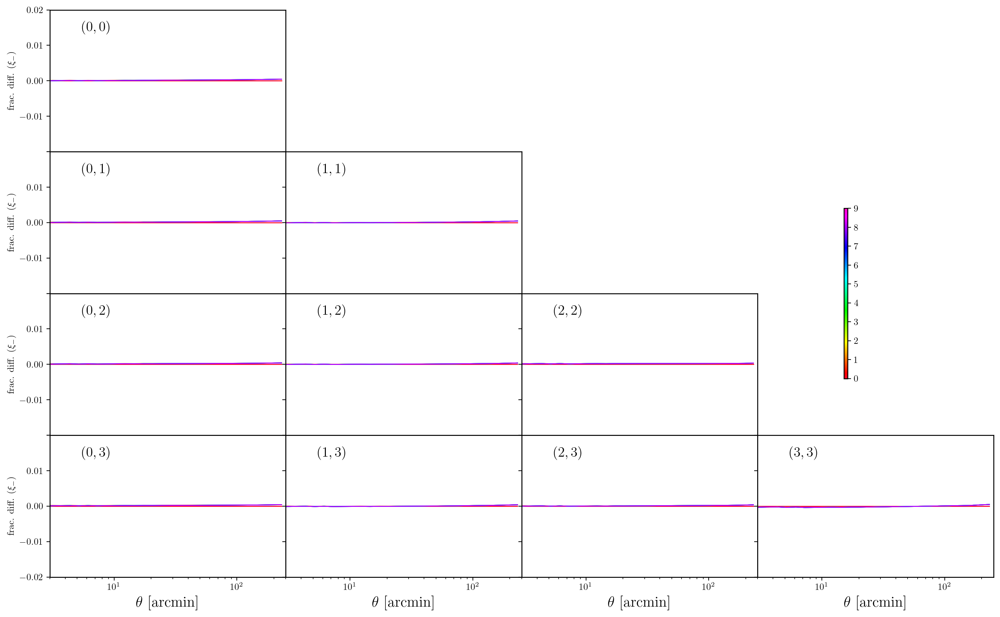

In [32]:
cnu.plot_xi(pm=0,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            param=param,
            ylim=(0.98,1.02),
            yaxislabelsize = 10,
            xaxisticklabelsize=10,
            yaxisticklabelsize=10,
            figsize = (18, 11),
            wspace=0.4)

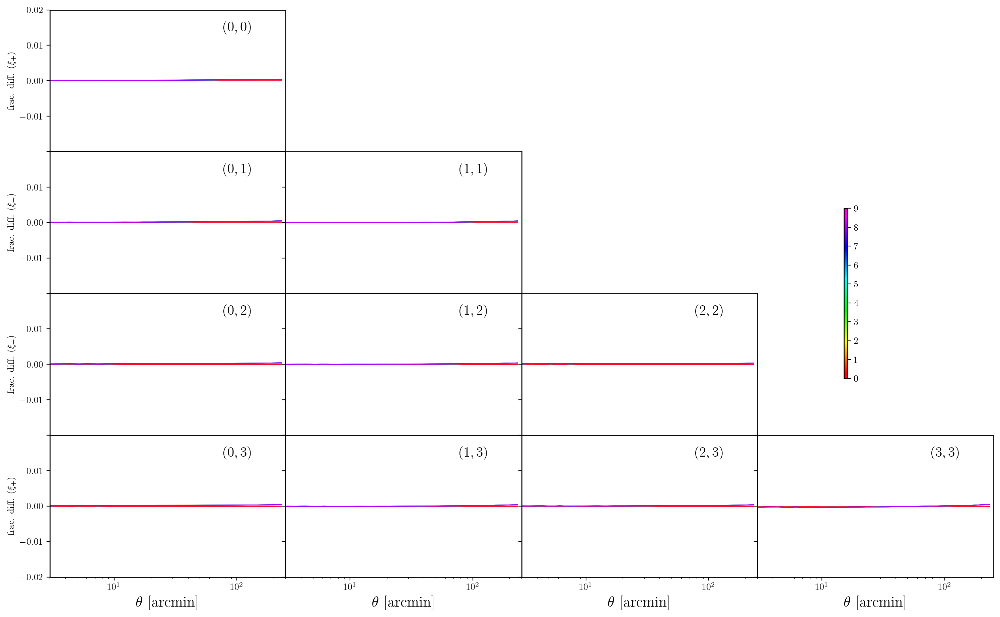

In [33]:
cnu.plot_xi(pm=1,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            param=param,
            ylim=(0.98,1.02),
            yaxislabelsize = 10,
            xaxisticklabelsize=10,
            yaxisticklabelsize=10,
            figsize = (18, 11),
            wspace=0.4)

In [34]:
lmin = 100.
lmax = 6500.
ell = np.arange(lmin, lmax, 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(1.,6.0,1.0)
C_ss = []
for x in param:
    # Change only CAMB Settings
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, AccuracyBoost=1,CAMBAccuracyBoost=1.+x/3,CLAccuracyBoost=1,CLIntegrationAccuracy=0)
    C_ss.append(Cl)
# Plot the Ratio over ref cosmology
(C_ss_ref, tmp) = nw.C_ss_tomo_limber(ell=ell,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)

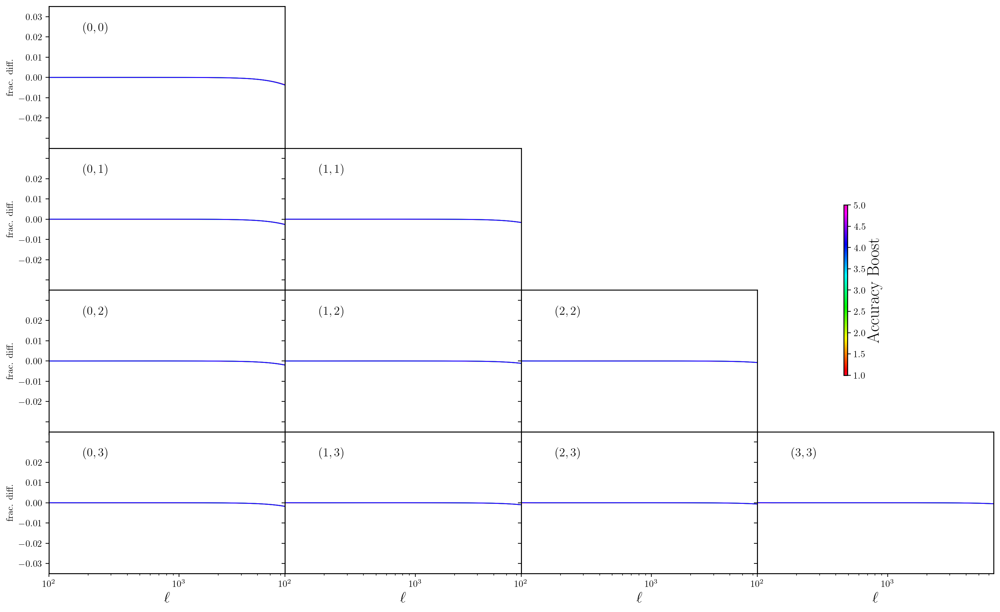

In [35]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          param=param,
                          lmin=lmin,
                          lmax=lmax,
                          ylim=(0.965,1.035),
                          colorbarlabel="Accuracy Boost",
                          yaxislabelsize = 10,
                          xaxisticklabelsize=10,
                          yaxisticklabelsize=10,
                          figsize = (18, 11),
                          wspace=0.4)

In [36]:
param = np.arange(1.,6.0,1.0)
xi_theta_ref = nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)
xi_theta = []
for x in param:
    xi_theta.append(nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1+x/3,CLAccuracyBoost=1,CLIntegrationAccuracy=0))

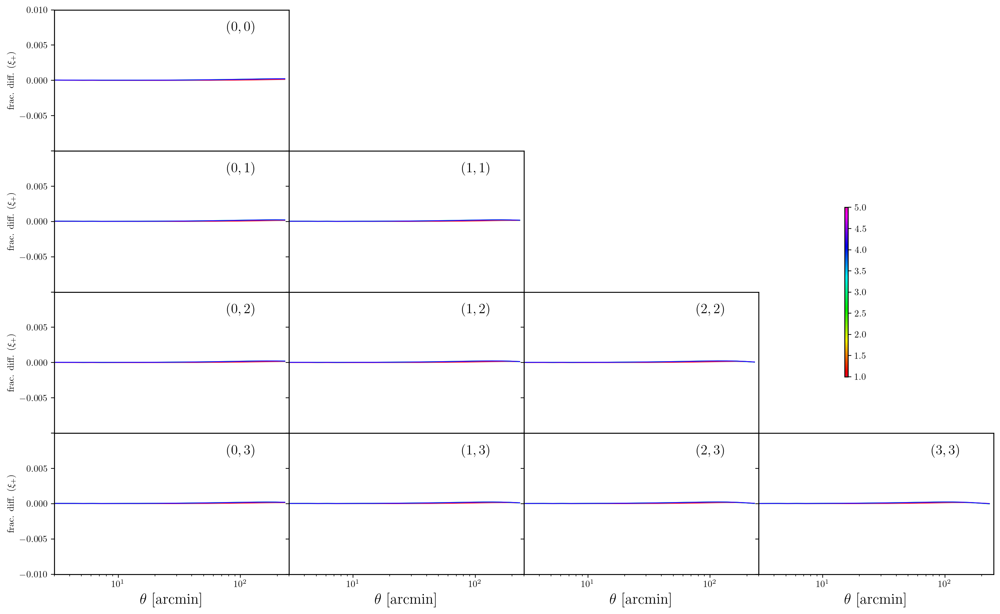

In [37]:
cnu.plot_xi(pm = 1,
            xi = xi_theta,
            xi_ref = xi_theta_ref,
            param=param,
            ylim=(0.99, 1.01),
            yaxislabelsize = 10,
            xaxisticklabelsize=10,
            yaxisticklabelsize=10,
            figsize = (18, 11),
            wspace=0.4)

# Let's compute $\chi^2_{\rm DES\ Y3 \times Planck\ PR4}$ and reproduce the results shown on EXAMPLE_EVALUATE1.yaml

In [38]:
# Re-init with the chi2 machinery: probes, covariance, mask, and
# data vector (nw.init_cosmolike holds the full sequence)
ini = nw.init_cosmolike(CLprobe="xi", with_data=True)
allsims = nw.allsims

In [39]:
nw.get_chi2(omegam = 0.3)

748.9043903032702

In [40]:
param = np.arange(0.295, 0.305, 0.001)      
chi2 = []
for x in param:
    chi2.append(nw.get_chi2(omegam = x))

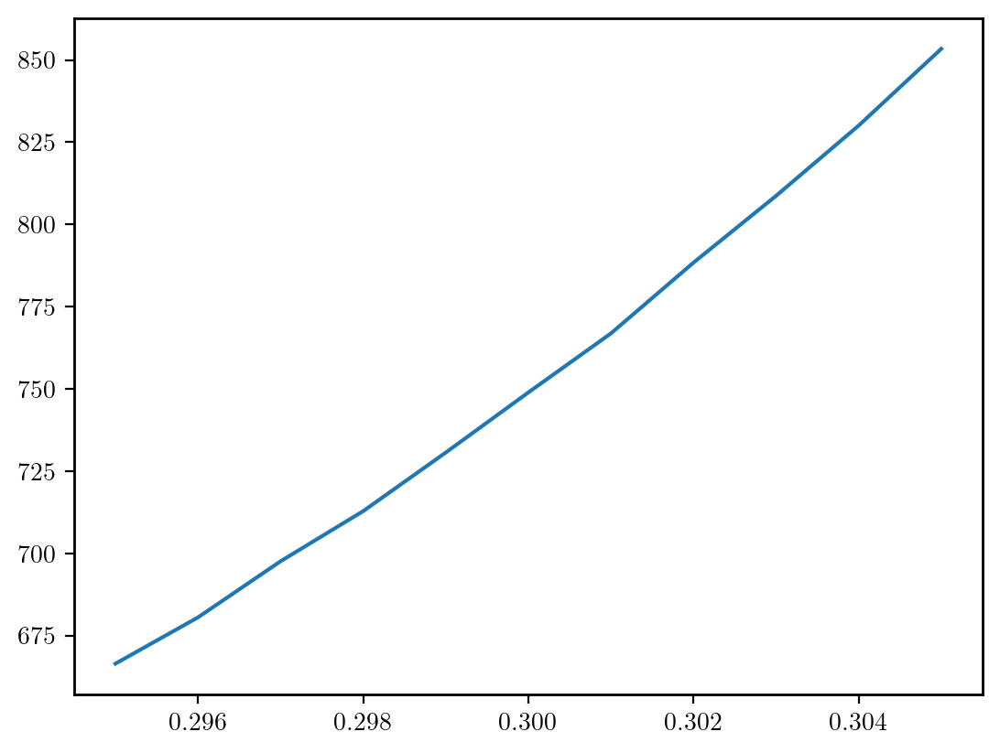

In [41]:
plt.plot(param, chi2)

# Let's compute $\chi^2_{\rm DES\ Y3 \times Planck\ PR4}$ as function of CAMB+Cosmolike Integration Accuracy

In [42]:
param = np.arange(0., 6., 0.5)      
chi2 = []
for x in param:
    chi2.append(nw.get_chi2(AccuracyBoost = 1, CAMBAccuracyBoost = 1.+ x/3.0, CLAccuracyBoost = 1 + x, CLIntegrationAccuracy = 1))
chi2 = np.array(chi2)

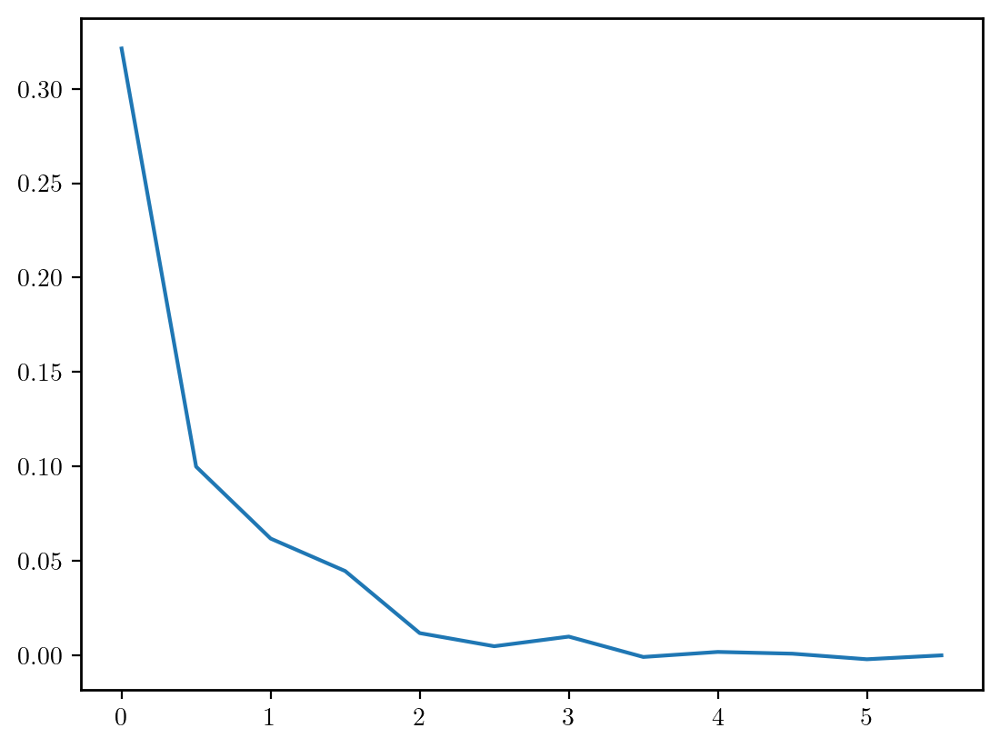

In [43]:
plt.plot(param, np.array(chi2 - chi2[-1]))

In [44]:
# Do we get the similar behaviour by just changing AccuracyBoost (which we design to change all parameters at once)
param = np.arange(0, 6, 0.5)      
chi2 = []
for x in param:
    chi2.append(nw.get_chi2(AccuracyBoost = 1 + x))
chi2 = np.array(chi2)

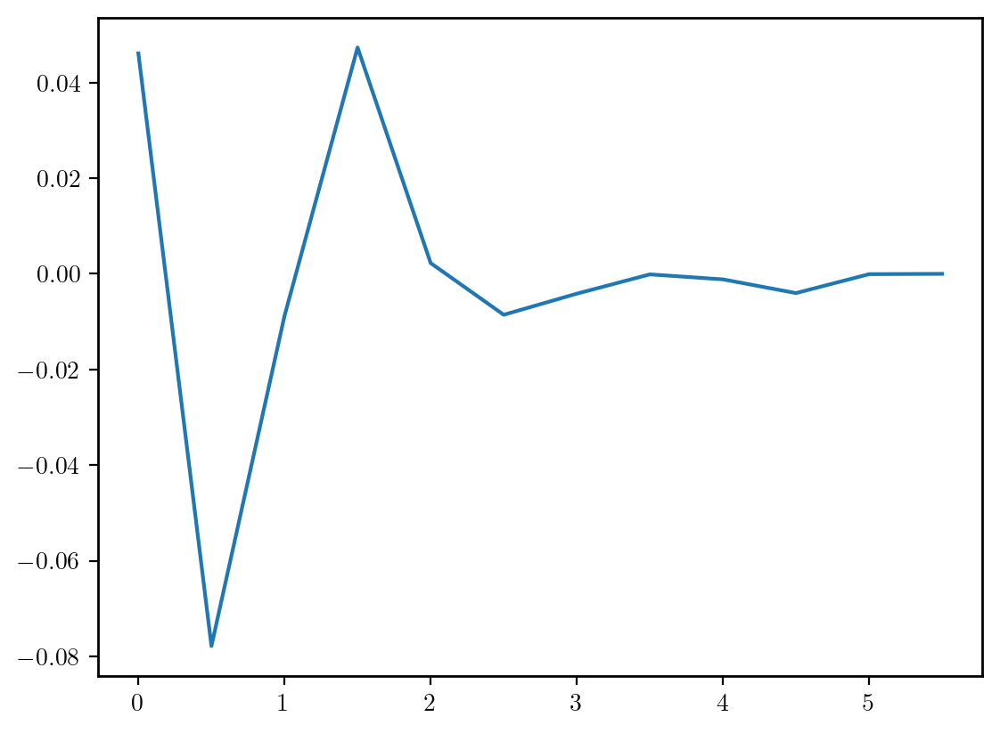

In [45]:
plt.plot(param, np.array(chi2 - chi2[-1]))

# Let's Plot HALOFIT VS EE2

In [46]:
print(rf"$\chi^2$={nw.get_chi2(non_linear_emul=1):3.3f}")
print(rf"$\chi^2$={nw.get_chi2(non_linear_emul=2):3.3f}")

/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/euclidemu2/ee2_bindata.dat
$\chi^2$=723.207


$\chi^2$=748.904


In [47]:
lmin = 100.
lmax = 6500.
ell = np.arange(lmin, lmax, 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = [1]
C_ss = []
for x in param:
    # Change only Cosmolike Settings
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=2)
    C_ss.append(Cl)
(C_ss_ref, tmp) = nw.C_ss_tomo_limber(ell=ell,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=1)

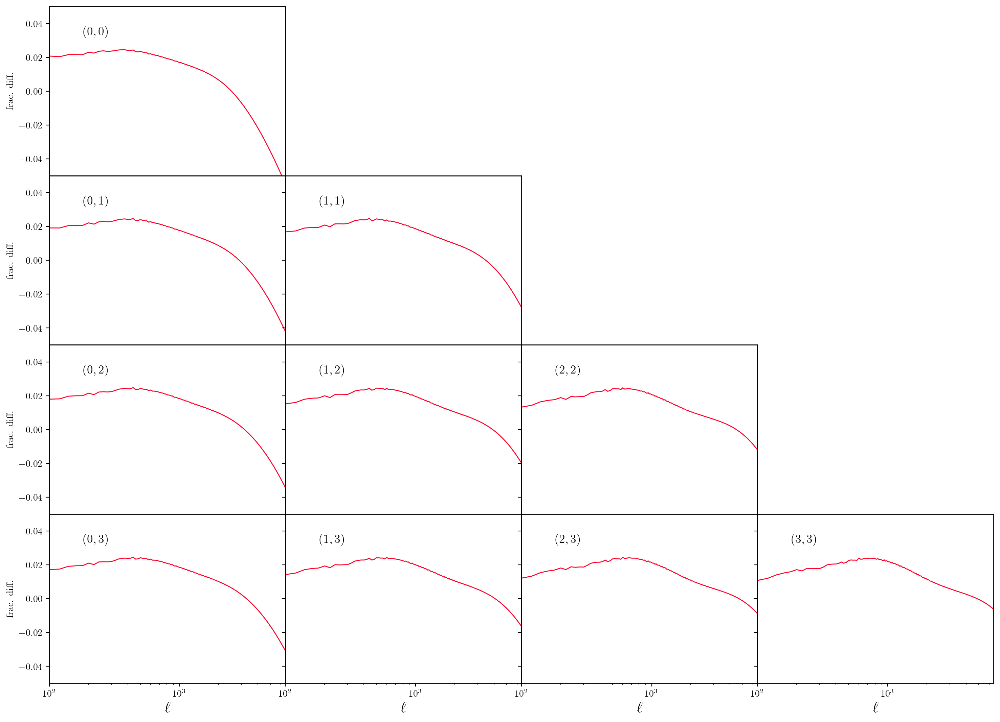

In [48]:
# Plot the Ratio over ref cosmology
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          param=param,
                          lmin=lmin,
                          lmax=lmax,
                          ylim=(0.95,1.05),
                          colorbarlabel="Accuracy Boost",
                          colorbar=None,
                          yaxislabelsize = 10,
                          xaxisticklabelsize=10,
                          yaxisticklabelsize=10,
                          figsize = (18, 13),
                          wspace=0.3)

In [49]:
param = [1]
xi_theta_ref = nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=2)
xi_theta = []
for x in param:
    xi_theta.append(nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1+x/3,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=1))

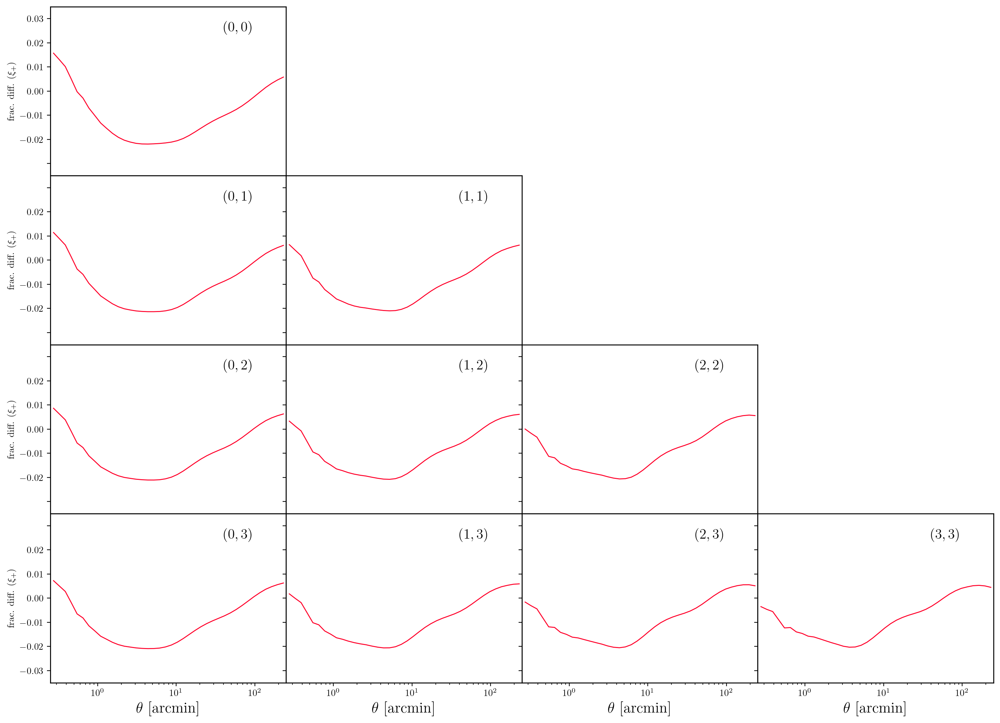

In [50]:
cnu.plot_xi(pm = 1,
            xi = xi_theta,
            xi_ref = xi_theta_ref,
            param=param,
            ylim=(0.965, 1.035),
            colorbar=None,
            yaxislabelsize = 10,
            xaxisticklabelsize=10,
            yaxisticklabelsize=10,
            figsize = (18, 13),
            thetashow=[0.25,250],
            wspace=0.3)

# Plot Reponse Function $d\ln C_{\mathrm{ss}}^{\mathrm{EE}} \big/ d\ln k$ (normalized)

In [51]:
# dlnC_dlss_tomo_limber lives in this project's interface/
# (cosmolike_desy1xplanck_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.dlnC_dlss_tomo_limber.

In [52]:
ell  = [30.,300.,3000.]
kk = 10.0 ** np.arange(-2.2, 1.6, 0.025)
(dlnCEEdlnk, tmp) = nw.dlnC_dlss_tomo_limber(k=kk, ell=ell, CLAccuracyBoost=1.00)

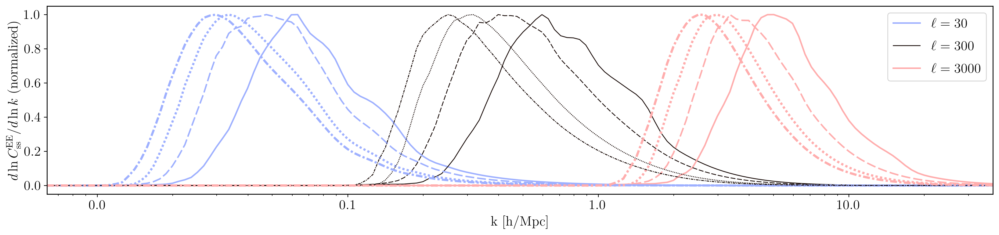

In [53]:
cnu.plot_response_function(k=kk,
                           resp=dlnCEEdlnk,
                           labels=[r"$\ell=30$", r"$\ell=300$", r"$\ell=3000$"],
                           ylabel=r"$d\ln C_{\mathrm{ss}}^{\mathrm{EE}} / d\ln k$ (normalized)",
                           normalize=True,
                           xtickformat="scalar")


# Plot Reponse Function $d\ln \xi_{\pm} \big/ d\ln k$ (normalized)

In [54]:
# dlnxi_dlnk_pm_tomo_limber lives in this project's interface/
# (cosmolike_desy1xplanck_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.dlnxi_dlnk_pm_tomo_limber.

In [55]:
kk = 10.0**np.arange(-3., 1.02, 0.02)

In [56]:
(theta, dlnxip_dlnk, dlnxim_dlnk) = nw.dlnxi_dlnk_pm_tomo_limber(k = kk)

In [57]:
print(theta)

[0.2836022963386458, 0.35703413770390113, 0.44947934883345914, 0.5658609743231364, 0.7123767601180032, 0.8968292060841517, 1.1290410775785265, 1.4213785035230764, 1.7894095178631664, 2.2527331141442906, 2.8360229633864567, 3.570341377039011, 4.494793488334589, 5.658609743231364, 7.12376760118003, 8.968292060841518, 11.290410775785269, 14.21378503523077, 17.894095178631662, 22.527331141442893, 28.36022963386455, 35.70341377039008, 44.94793488334587, 56.58609743231363, 71.2376760118003, 89.68292060841516, 112.90410775785266, 142.13785035230768, 178.9409517863167, 225.27331141442897]


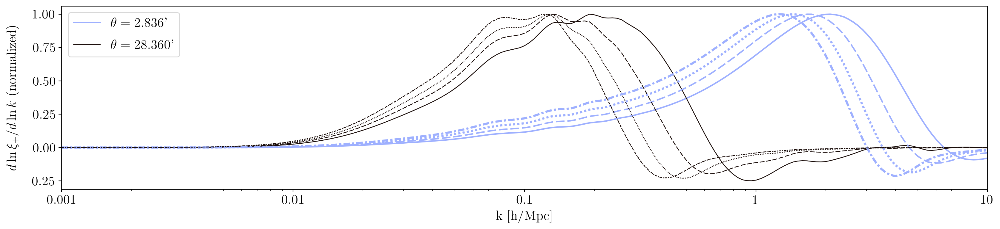

In [58]:
idx = [10, 20]
cnu.plot_response_function(k=kk,
                           resp=dlnxip_dlnk,
                           labels=[rf"$\theta={theta[i]:.3f}$'" for i in idx],
                           idx=idx,
                           ncolors=3,
                           ylabel=r"$d\ln \xi_{+} / d\ln k$ (normalized)",
                           normalize=True)


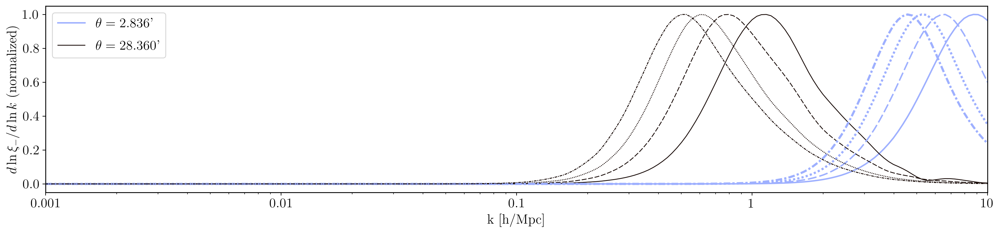

In [59]:
cnu.plot_response_function(k=kk,
                           resp=dlnxim_dlnk,
                           labels=[rf"$\theta={theta[i]:.3f}$'" for i in idx],
                           idx=idx,
                           ncolors=3,
                           ylabel=r"$d\ln \xi_{-} / d\ln k$ (normalized)",
                           normalize=True)


# Plot Reponse Function $\int_{-\infty}^{\ln k_\alpha} d\ln k \big|d\ln C_{\mathrm{ss}}^{\mathrm{EE}} (\ell)\big/d\ln k\big| \bigg/ \int_{-\infty}^{\infty} d\ln k \big|d\ln C_{\mathrm{ss}}^{\mathrm{EE}}(\ell) \big/d\ln k\big|$ as a function of $k_\alpha$

In [60]:
# rf_C_ss_tomo_limber lives in this project's interface/
# (cosmolike_desy1xplanck_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.rf_C_ss_tomo_limber.

In [61]:
ell  = [30.,300.,3000.]
kk = 10.0 ** np.arange(-2.2, 1.6, 0.05)
(rfCEE, tmp) = nw.rf_C_ss_tomo_limber(k=kk, ell=ell, CLAccuracyBoost=1.00, CLIntegrationAccuracy=0)

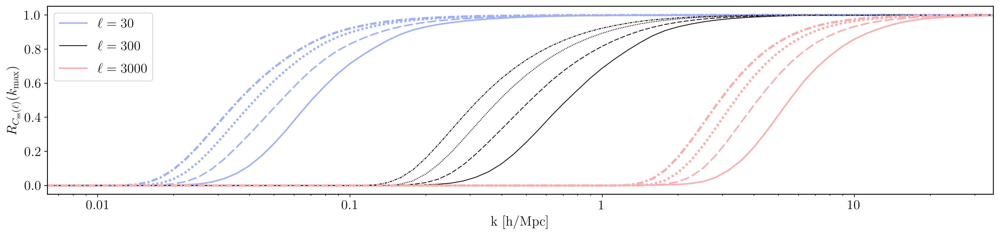

In [62]:
cnu.plot_response_function(k=kk,
                           resp=rfCEE,
                           labels=[r"$\ell=30$", r"$\ell=300$", r"$\ell=3000$"],
                           ylabel=r"$R_{C_{\mathrm{ss}}(\ell)}(k_{\mathrm{max}})$",
                           normalize=False)


# Plot Reponse Function $\int_{-\infty}^{\ln k_\alpha} d\ln k \big|d\ln \xi_{\pm} (\theta)\big/d\ln k\big| \bigg/ \int_{-\infty}^{\infty} d\ln k \big|d\ln \xi_{\pm}(\ell) \big/d\ln k\big|$ as a function of $k_\alpha$

In [63]:
# rf_xi_tomo_limber lives in this project's interface/
# (cosmolike_desy1xplanck_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.rf_xi_tomo_limber.

In [64]:
kk = 10.0 ** np.arange(-2, 1.2, 0.02)

In [65]:
(theta, rf_xip, rf_xim) = nw.rf_xi_tomo_limber(k = kk)

In [66]:
print(theta)

[0.2836022963386458, 0.35703413770390113, 0.44947934883345914, 0.5658609743231364, 0.7123767601180032, 0.8968292060841517, 1.1290410775785265, 1.4213785035230764, 1.7894095178631664, 2.2527331141442906, 2.8360229633864567, 3.570341377039011, 4.494793488334589, 5.658609743231364, 7.12376760118003, 8.968292060841518, 11.290410775785269, 14.21378503523077, 17.894095178631662, 22.527331141442893, 28.36022963386455, 35.70341377039008, 44.94793488334587, 56.58609743231363, 71.2376760118003, 89.68292060841516, 112.90410775785266, 142.13785035230768, 178.9409517863167, 225.27331141442897]


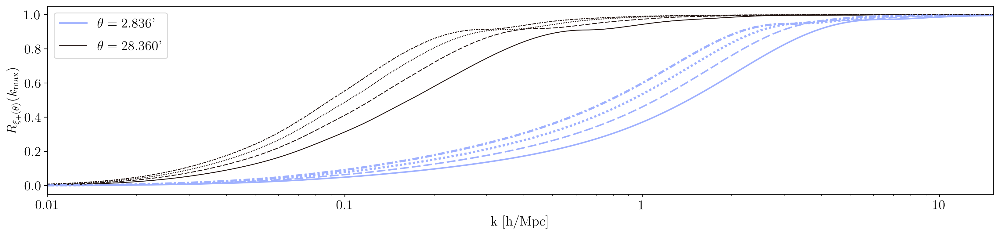

In [67]:
idx = [10, 20]
cnu.plot_response_function(k=kk,
                           resp=rf_xip,
                           labels=[rf"$\theta={theta[i]:.3f}$'" for i in idx],
                           idx=idx,
                           ncolors=3,
                           ylabel=r"$R_{\xi_+(\theta)}(k_{\mathrm{max}})$",
                           normalize=False)


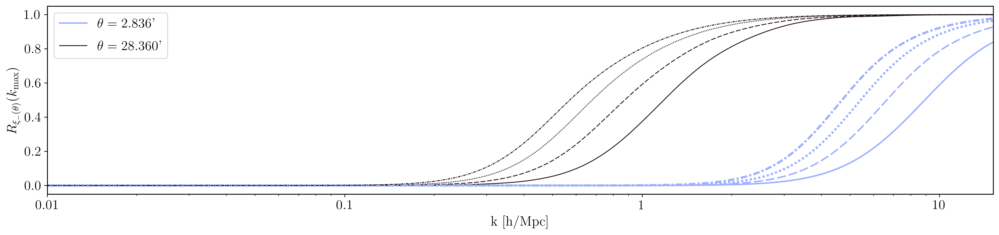

In [68]:
cnu.plot_response_function(k=kk,
                           resp=rf_xim,
                           labels=[rf"$\theta={theta[i]:.3f}$'" for i in idx],
                           idx=idx,
                           ncolors=3,
                           ylabel=r"$R_{\xi_-(\theta)}(k_{\mathrm{max}})$",
                           normalize=False)


# CMB lensing $\times$ shear: $C_\ell^{\kappa s}$ and $w_{\kappa s}(\theta)$

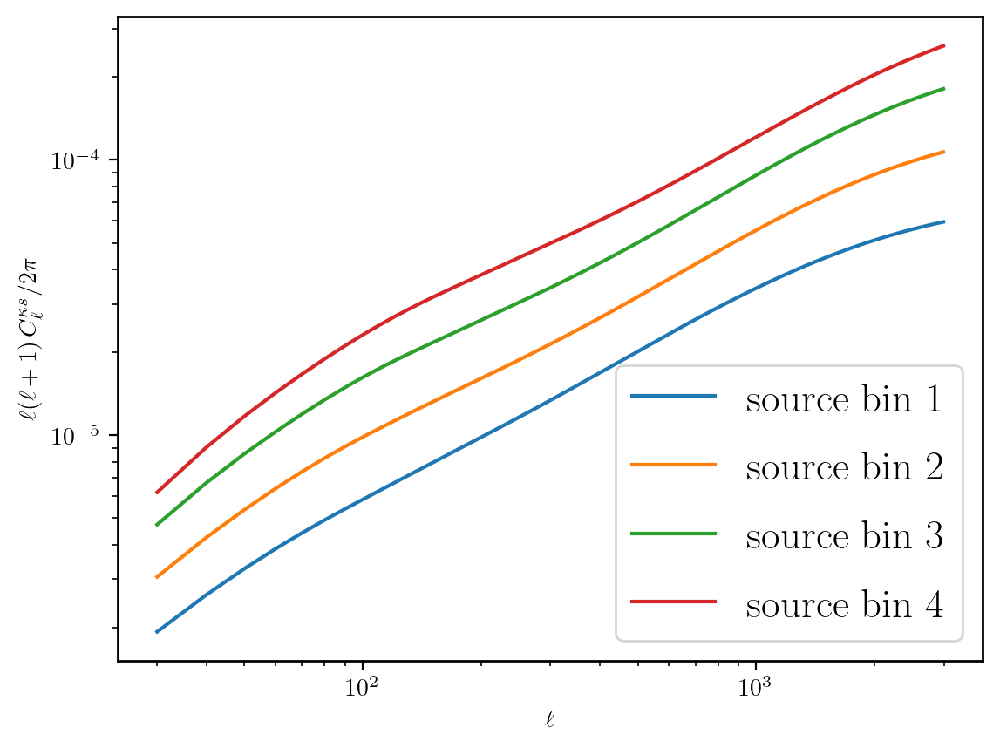

In [69]:
# C_ks_tomo_limber, w_ks, and their scale-cut diagnostics live in this
# project's interface/ (cosmolike_desy1xplanck_notebook_wrappers,
# imported above as nw); the CMB beam/pixel-window filter entering the
# w_ks projection was initialized by nw.init_cosmolike from the
# .dataset keys.
lmin = 30.
lmax = 3000.
ell = np.arange(lmin, lmax, 10.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
Cks = np.array(nw.C_ks_tomo_limber(ell=ell))
for b in range(Cks.shape[1]):
    plt.loglog(ell, ell*(ell + 1)*Cks[:, b]/(2*np.pi),
               label=rf"source bin {b + 1}")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)\, C_\ell^{\kappa s}/2\pi$")
plt.legend()

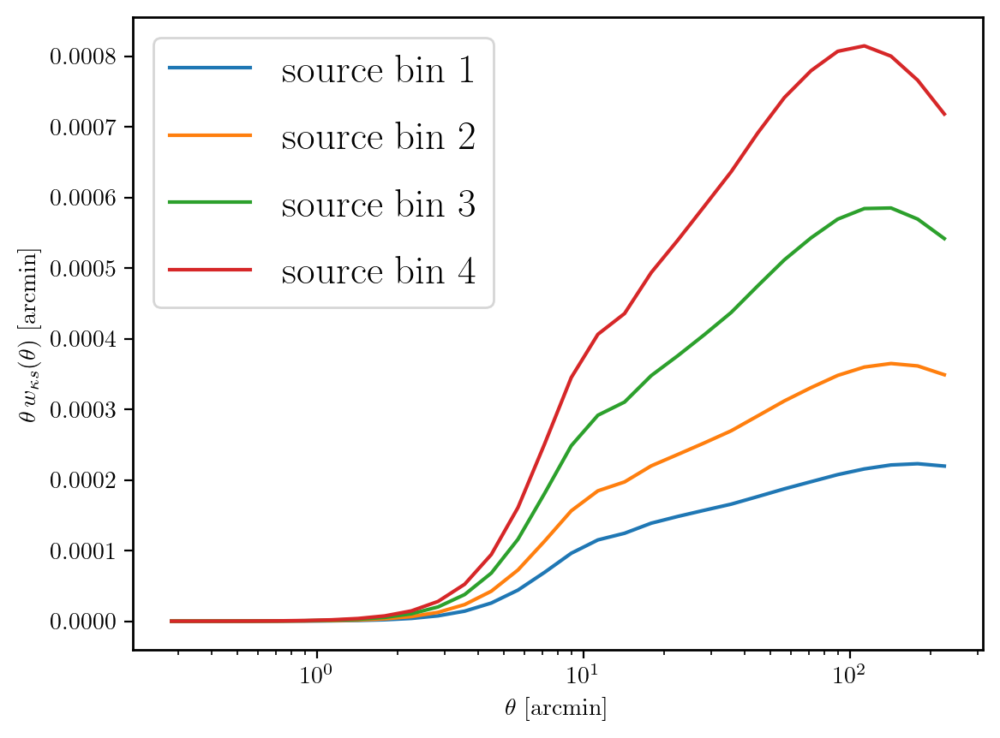

In [70]:
(theta, wks) = nw.w_ks()
wks = np.array(wks)
for b in range(wks.shape[1]):
    plt.semilogx(theta, theta*wks[:, b], label=rf"source bin {b + 1}")
plt.xlabel(r"$\theta$ [arcmin]")
plt.ylabel(r"$\theta\, w_{\kappa s}(\theta)$ [arcmin]")
plt.legend()

# Plot Response Function $d\ln C_{\kappa s} \big/ d\ln k$ (normalized)

In [71]:
ell  = [30.,300.,3000.]
kk = 10.0 ** np.arange(-2.2, 1.6, 0.025)
dlnCks = nw.dlnC_ks_dlnk_tomo_limber(k=kk, ell=ell)

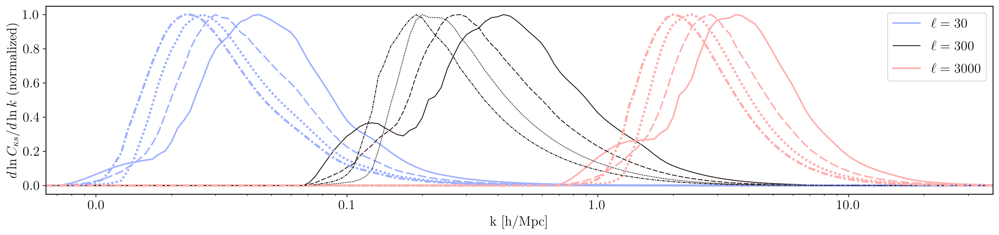

In [72]:
cnu.plot_response_function(k=kk,
                           resp=dlnCks,
                           labels=[r"$\ell=30$", r"$\ell=300$", r"$\ell=3000$"],
                           ylabel=r"$d\ln C_{\kappa s} / d\ln k$ (normalized)",
                           normalize=True,
                           xtickformat="scalar")


# Plot Response Function $d\ln w_{\kappa s} \big/ d\ln k$ (normalized)

In [73]:
kk = 10.0**np.arange(-3., 1.02, 0.02)
(theta, dlnwks) = nw.dlnw_ks_dlnk_tomo(k = kk)
print(theta)

[0.2836022963386458, 0.35703413770390113, 0.44947934883345914, 0.5658609743231364, 0.7123767601180032, 0.8968292060841517, 1.1290410775785265, 1.4213785035230764, 1.7894095178631664, 2.2527331141442906, 2.8360229633864567, 3.570341377039011, 4.494793488334589, 5.658609743231364, 7.12376760118003, 8.968292060841518, 11.290410775785269, 14.21378503523077, 17.894095178631662, 22.527331141442893, 28.36022963386455, 35.70341377039008, 44.94793488334587, 56.58609743231363, 71.2376760118003, 89.68292060841516, 112.90410775785266, 142.13785035230768, 178.9409517863167, 225.27331141442897]


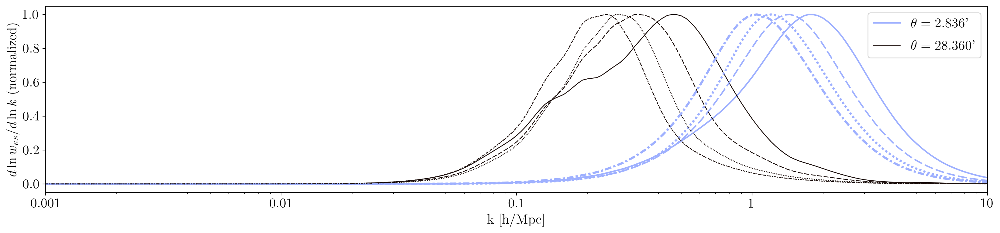

In [74]:
idx = [10, 20]
cnu.plot_response_function(k=kk,
                           resp=dlnwks,
                           labels=[rf"$\theta={theta[i]:.3f}$'" for i in idx],
                           idx=idx,
                           ncolors=3,
                           ylabel=r"$d\ln w_{\kappa s} / d\ln k$ (normalized)",
                           normalize=True)


# Plot Response Function $\int_{-\infty}^{\ln k_\alpha} d\ln k \big|d\ln C_{\kappa s} (\ell)\big/d\ln k\big| \bigg/ \int_{-\infty}^{\infty} d\ln k \big|d\ln C_{\kappa s}(\ell) \big/d\ln k\big|$ as a function of $k_\alpha$

In [75]:
ell  = [30.,300.,3000.]
kk = 10.0 ** np.arange(-2.2, 1.6, 0.05)
rfCks = nw.rf_C_ks_tomo_limber(k=kk, ell=ell)

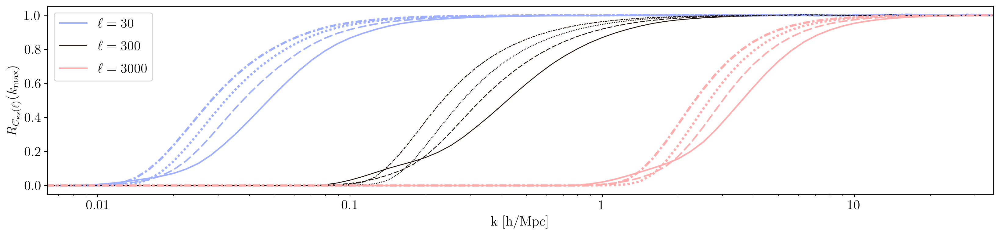

In [76]:
cnu.plot_response_function(k=kk,
                           resp=rfCks,
                           labels=[r"$\ell=30$", r"$\ell=300$", r"$\ell=3000$"],
                           ylabel=r"$R_{C_{\kappa s}(\ell)}(k_{\mathrm{max}})$",
                           normalize=False)


# Plot Response Function $\int_{-\infty}^{\ln k_\alpha} d\ln k \big|d\ln w_{\kappa s} (\theta)\big/d\ln k\big| \bigg/ \int_{-\infty}^{\infty} d\ln k \big|d\ln w_{\kappa s}(\theta) \big/d\ln k\big|$ as a function of $k_\alpha$

In [77]:
kk = 10.0 ** np.arange(-2, 1.2, 0.02)
(theta, rfwks) = nw.rf_w_ks_tomo(k = kk)
print(theta)

[0.2836022963386458, 0.35703413770390113, 0.44947934883345914, 0.5658609743231364, 0.7123767601180032, 0.8968292060841517, 1.1290410775785265, 1.4213785035230764, 1.7894095178631664, 2.2527331141442906, 2.8360229633864567, 3.570341377039011, 4.494793488334589, 5.658609743231364, 7.12376760118003, 8.968292060841518, 11.290410775785269, 14.21378503523077, 17.894095178631662, 22.527331141442893, 28.36022963386455, 35.70341377039008, 44.94793488334587, 56.58609743231363, 71.2376760118003, 89.68292060841516, 112.90410775785266, 142.13785035230768, 178.9409517863167, 225.27331141442897]


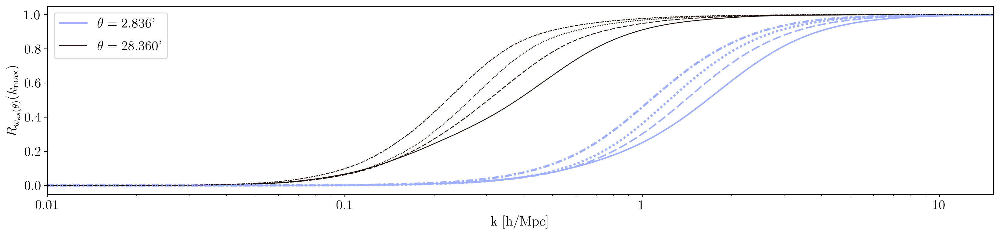

In [78]:
idx = [10, 20]
cnu.plot_response_function(k=kk,
                           resp=rfwks,
                           labels=[rf"$\theta={theta[i]:.3f}$'" for i in idx],
                           idx=idx,
                           ncolors=3,
                           ylabel=r"$R_{w_{\kappa s}(\theta)}(k_{\mathrm{max}})$",
                           normalize=False)
